# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных

**Дисциплина:** Технологии машинного обучения

**Цель работы:** изучение различных методов визуализации данных на примере одного из датасетов библиотеки `scikit-learn`.

**Состав работы:**
1. Текстовое описание выбранного набора данных.
2. Основные характеристики датасета.
3. Визуальное исследование датасета.
4. Информация о корреляции признаков.

## 1. Описание набора данных

Для выполнения работы выбран датасет **California Housing** из библиотеки `scikit-learn` ([fetch_california_housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)). Датасет составлен на основе переписи населения Калифорнии 1990 года и содержит агрегированные характеристики жилых округов (block groups).

**Размер:** 20 640 наблюдений, 8 числовых признаков, 1 целевая переменная. Пропусков в данных нет, что соответствует рекомендациям методических указаний.

**Признаки:**

| Признак | Описание |
|---|---|
| `MedInc` | Медианный доход домохозяйств (десятки тыс. долларов) |
| `HouseAge` | Медианный возраст жилых построек (годы) |
| `AveRooms` | Среднее число комнат на домохозяйство |
| `AveBedrms` | Среднее число спален на домохозяйство |
| `Population` | Население округа |
| `AveOccup` | Средняя заполняемость домохозяйства |
| `Latitude` | Широта округа |
| `Longitude` | Долгота округа |

**Целевая переменная** `MedHouseVal` — медианная стоимость жилья в округе (сотни тыс. долларов, ограничена сверху значением 5.0).

**Задача:** регрессия — предсказание медианной стоимости жилья по характеристикам округа. В рамках данной работы решение задачи регрессии не выполняется; задача используется как мотивация для исследования распределений и взаимосвязей признаков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [2]:
raw = fetch_california_housing(as_frame=True)
df = raw.frame.rename(columns={'MedHouseVal': 'MedHouseVal'})
TARGET = 'MedHouseVal'
FEATURES = [c for c in df.columns if c != TARGET]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526
1,8.301,21.000,6.238,0.972,"2,401.000",2.110,37.860,-122.220,3.585
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422


## 2. Основные характеристики датасета

Проверим размер, типы данных, статистические сводки и наличие пропусков.

In [3]:
print(f'Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов')
print(f'Признаков: {len(FEATURES)}, целевая переменная: {TARGET}')

Размер датасета: 20640 наблюдений, 9 столбцов
Признаков: 8, целевая переменная: MedHouseVal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,"20,640.000",3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,"20,640.000",28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,"20,640.000",5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,"20,640.000",1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,"20,640.000","1,425.477","1,132.462",3.000,787.000,"1,166.000","1,725.000","35,682.000"
AveOccup,"20,640.000",3.071,10.386,0.692,2.430,2.818,3.282,"1,243.333"
Latitude,"20,640.000",35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,"20,640.000",-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,"20,640.000",2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [6]:
missing = df.isna().sum()
missing.to_frame(name='Пропусков').assign(**{'Доля, %': (missing / len(df) * 100).round(3)})

,Пропусков,"Доля, %"
MedInc,0,0.000
HouseAge,0,0.000
AveRooms,0,0.000
AveBedrms,0,0.000
Population,0,0.000
AveOccup,0,0.000
Latitude,0,0.000
Longitude,0,0.000
MedHouseVal,0,0.000


**Промежуточные наблюдения:**

* Все признаки являются числовыми (`float64`), пропусков нет — дополнительная очистка не требуется.
* Признаки `AveRooms`, `AveBedrms`, `Population`, `AveOccup` имеют большие максимальные значения относительно медианы — это указывает на наличие выбросов и сильную правостороннюю асимметрию.
* Целевая переменная `MedHouseVal` ограничена сверху значением 5.0 (искусственное обрезание в исходных данных), что нужно учитывать при дальнейшей интерпретации.

## 3. Визуальное исследование датасета

### 3.1. Распределение целевой переменной

Гистограмма с ядерной оценкой плотности позволяет оценить форму распределения медианной стоимости жилья.

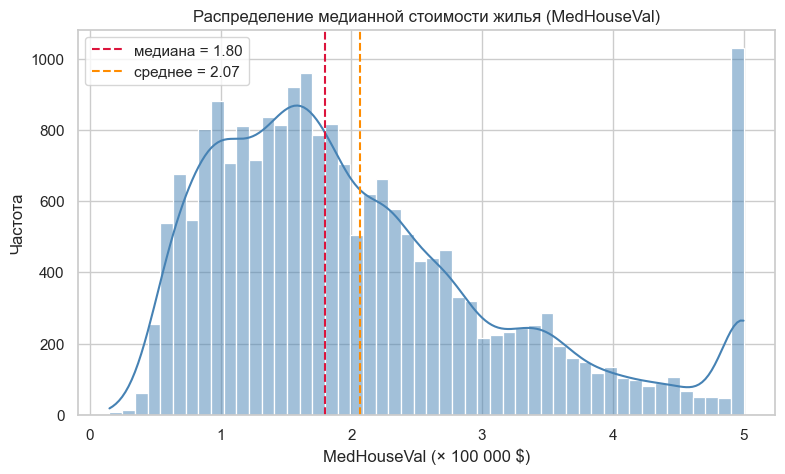

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df[TARGET], bins=50, kde=True, color='steelblue', ax=ax)
ax.axvline(df[TARGET].median(), color='crimson', linestyle='--', label=f'медиана = {df[TARGET].median():.2f}')
ax.axvline(df[TARGET].mean(), color='darkorange', linestyle='--', label=f'среднее = {df[TARGET].mean():.2f}')
ax.set_title('Распределение медианной стоимости жилья (MedHouseVal)')
ax.set_xlabel('MedHouseVal (× 100 000 $)')
ax.set_ylabel('Частота')
ax.legend()
plt.show()

Распределение **правосторонне асимметрично** (медиана < среднего), а на правом краю заметен «горб» — следствие обрезания значений на отметке 5.0.

### 3.2. Распределения признаков

Гистограммы признаков на одном полотне позволяют быстро сравнить их формы и масштабы.

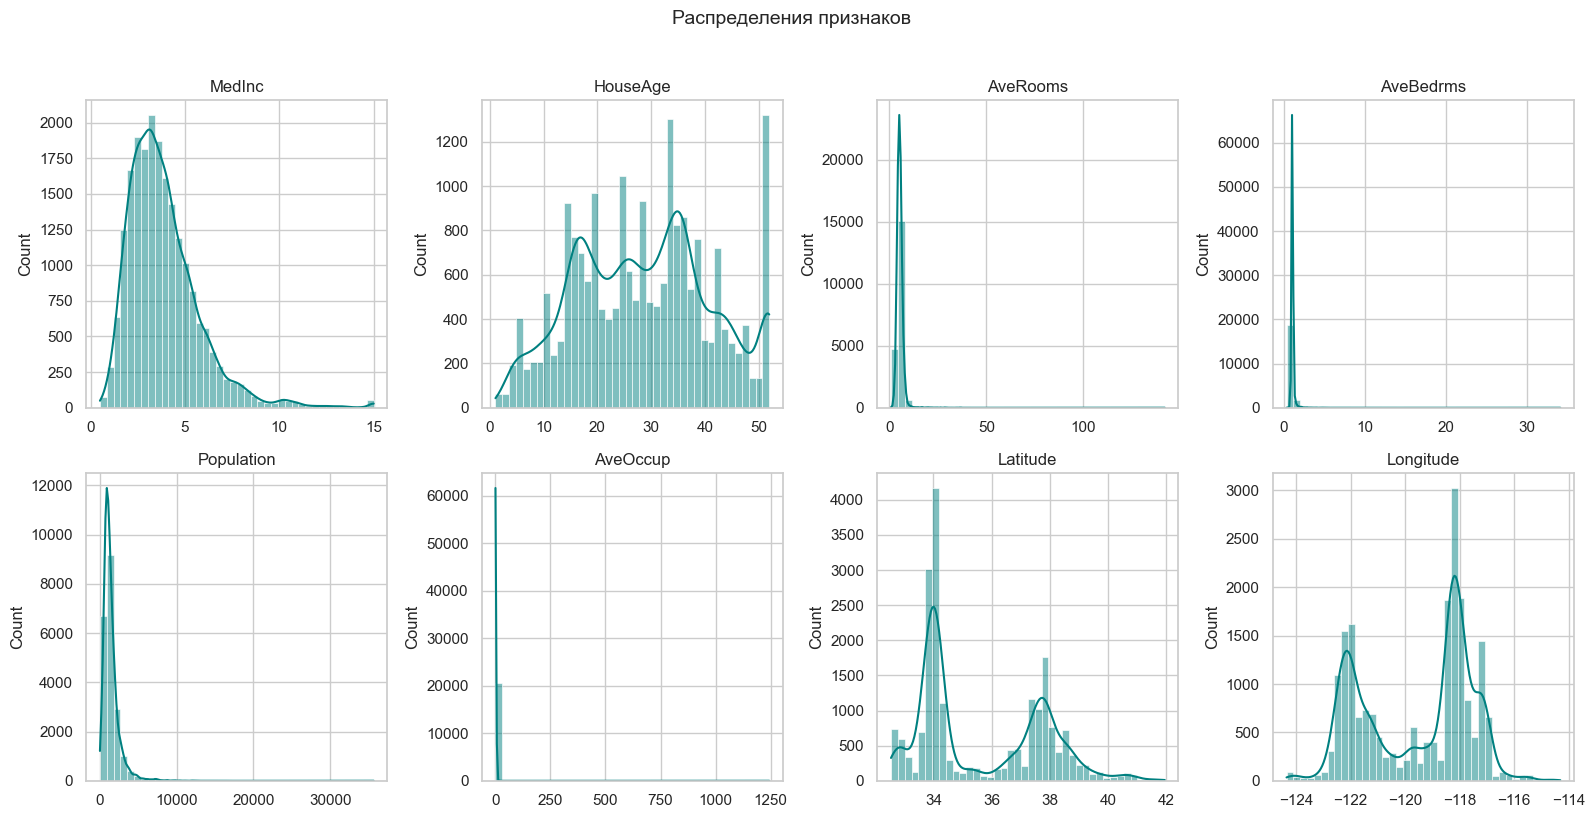

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(df[col], bins=40, kde=True, color='teal', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Распределения признаков', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

* `MedInc`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup` имеют сильную правостороннюю асимметрию и подозрительно «длинные хвосты» — кандидаты на логарифмирование при последующем обучении моделей.
* `HouseAge` распределена близко к равномерной с локальным пиком справа (тоже эффект искусственного обрезания).
* `Latitude` и `Longitude` бимодальны, что отражает расположение двух крупных агломераций — Лос-Анджелес (юг) и Сан-Франциско (север).

### 3.3. Боксплоты для оценки выбросов

Поскольку признаки сильно отличаются по масштабу, перед построением общего боксплота нормируем их.

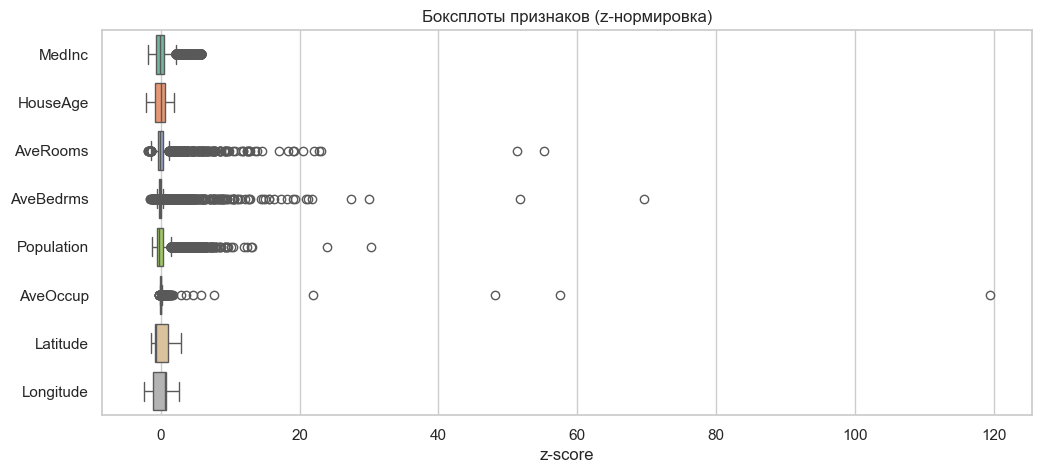

In [9]:
df_scaled = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_scaled, orient='h', palette='Set2', ax=ax)
ax.set_title('Боксплоты признаков (z-нормировка)')
ax.set_xlabel('z-score')
plt.show()

Чётко видны экстремальные выбросы в `AveRooms`, `AveBedrms`, `Population` и особенно `AveOccup` — наблюдения на уровне 10–100 стандартных отклонений. На практике такие записи стоит либо очищать, либо использовать робастные оценки.

### 3.4. Географическое распределение цен

Поскольку в данных есть координаты, естественно изобразить округа на двумерной карте, раскрасив их по целевой переменной.

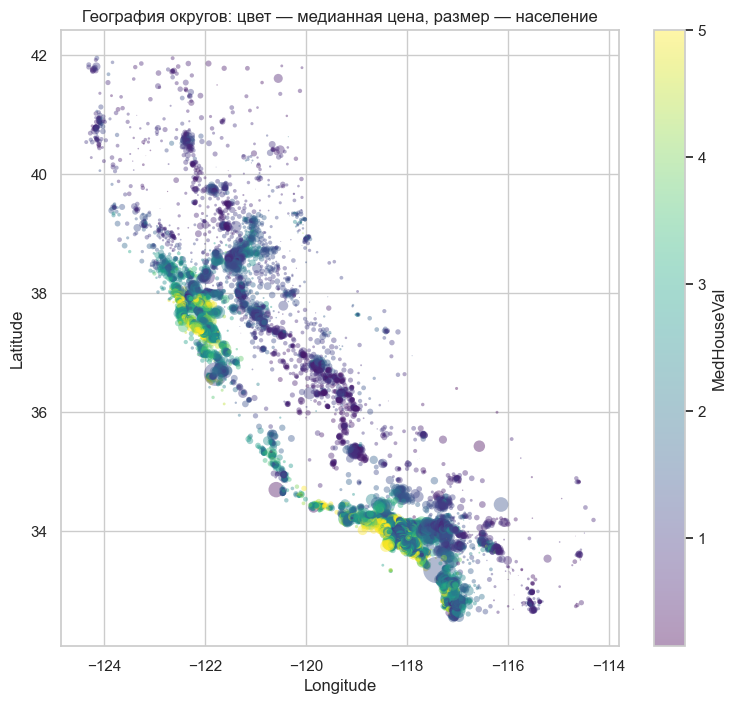

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    df['Longitude'], df['Latitude'],
    c=df[TARGET], cmap='viridis',
    s=df['Population'] / 100, alpha=0.4,
    edgecolor='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('MedHouseVal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('География округов: цвет — медианная цена, размер — население')
plt.show()

На карте отчётливо проступают два «жёлтых» кластера высокой стоимости жилья — побережье в районе Сан-Франциско и Лос-Анджелеса. Внутренние районы (восточнее) преимущественно дешёвые. Таким образом, координаты несут сильный сигнал для целевой переменной, хоть и нелинейный.

### 3.5. Парные диаграммы рассеяния (pairplot)

Для парного анализа возьмём подвыборку и наиболее информативные признаки, чтобы график оставался читаемым.

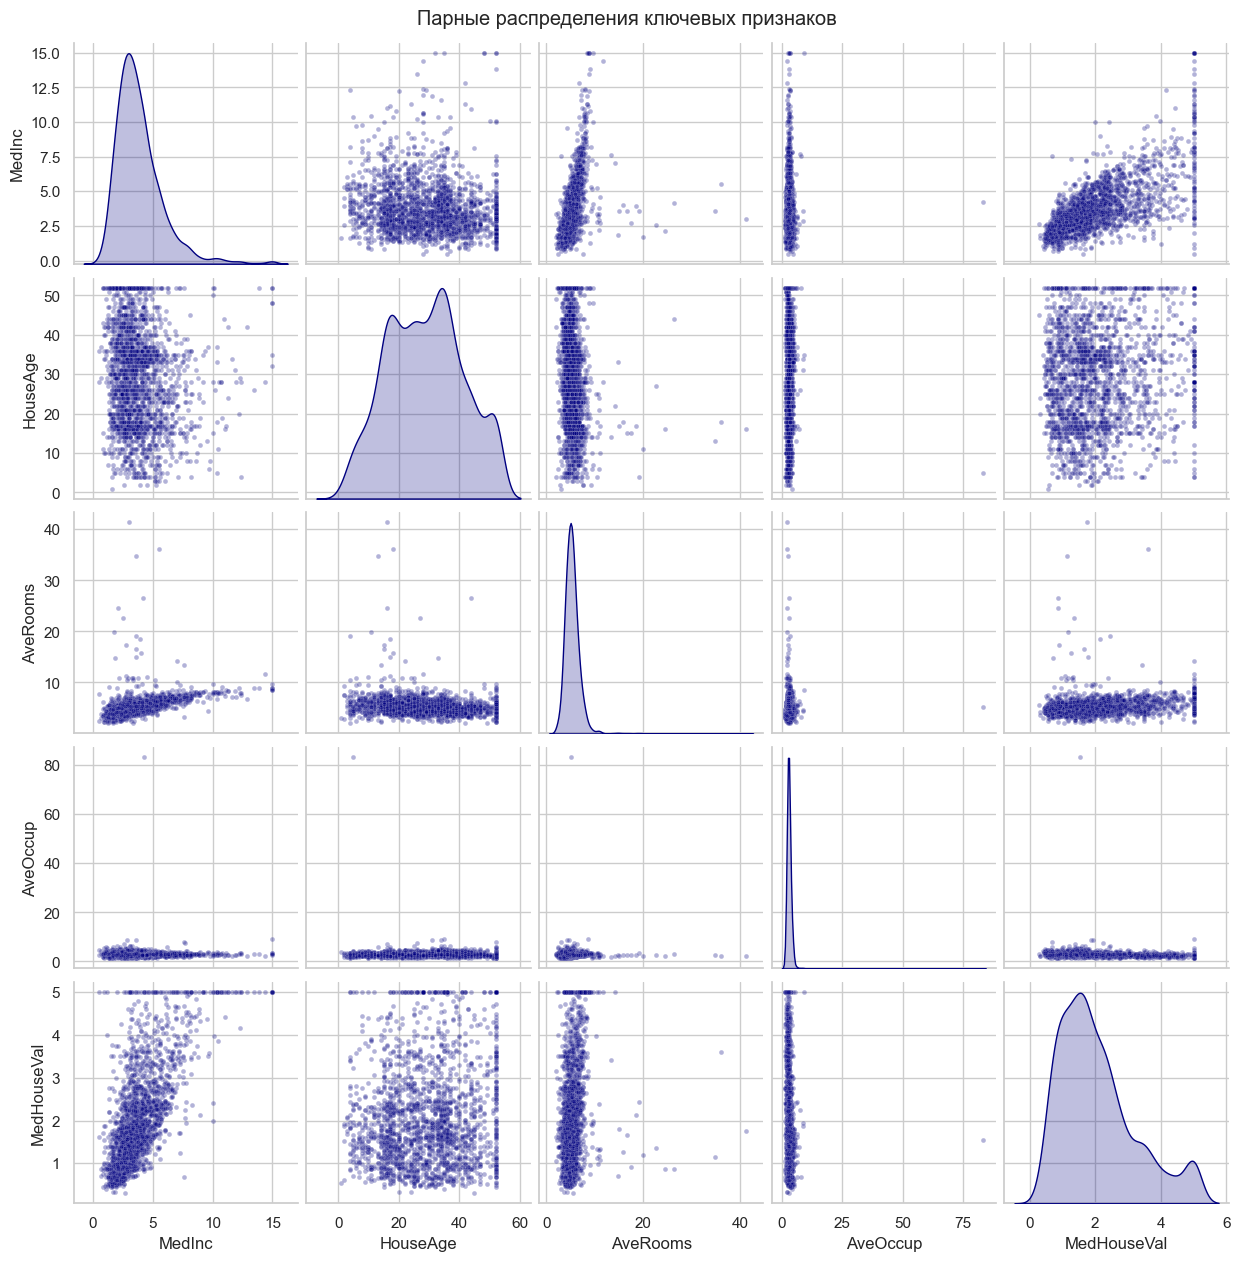

In [11]:
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', TARGET]
sample = df.sample(n=2000, random_state=42)
sns.pairplot(
    sample[subset_cols],
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 12, 'color': 'navy'},
    diag_kws={'color': 'navy'}
)
plt.suptitle('Парные распределения ключевых признаков', y=1.01)
plt.show()

* Между `MedInc` и `MedHouseVal` отчётливо просматривается положительная линейная связь.
* Между `AveRooms` и `AveOccup` видны крупные выбросы, которые «расширяют» оси и скрывают основную массу наблюдений.
* `HouseAge` слабо связан с другими признаками — пик плотности располагается равномерно по всем уровням `MedHouseVal`.

### 3.6. Совместное распределение наиболее связанной пары

Подробнее рассмотрим связь `MedInc` и `MedHouseVal` через `jointplot` с гексагональным биннингом.

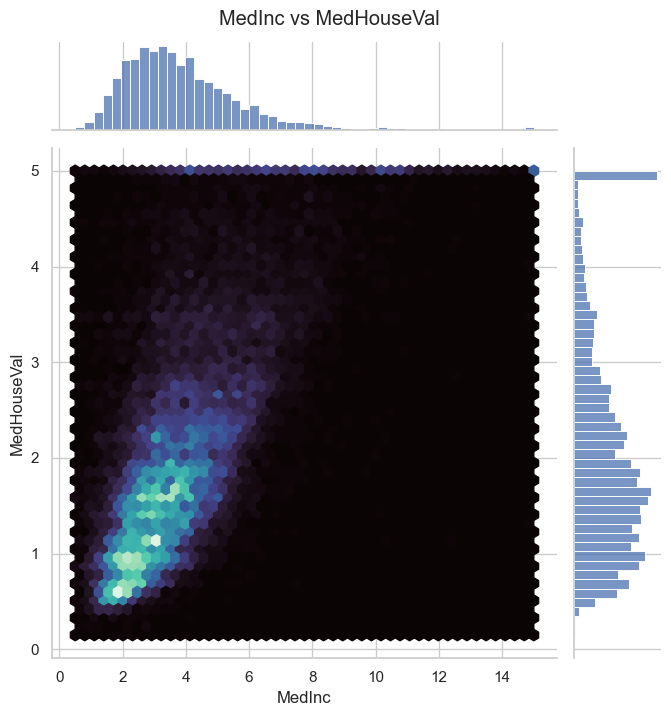

In [12]:
sns.jointplot(
    data=df, x='MedInc', y=TARGET,
    kind='hex', height=7, cmap='mako',
    marginal_kws={'bins': 50}
)
plt.suptitle('MedInc vs MedHouseVal', y=1.02)
plt.show()

Плотность основной массы наблюдений демонстрирует выраженный положительный тренд. Горизонтальная «полоса» сверху при `MedHouseVal = 5.0` — артефакт обрезания значений целевой переменной.

## 4. Корреляция признаков

Рассчитаем матрицу корреляций по Пирсону (линейная связь) и по Спирману (монотонная связь) — сравнение позволяет выявить нелинейные зависимости.

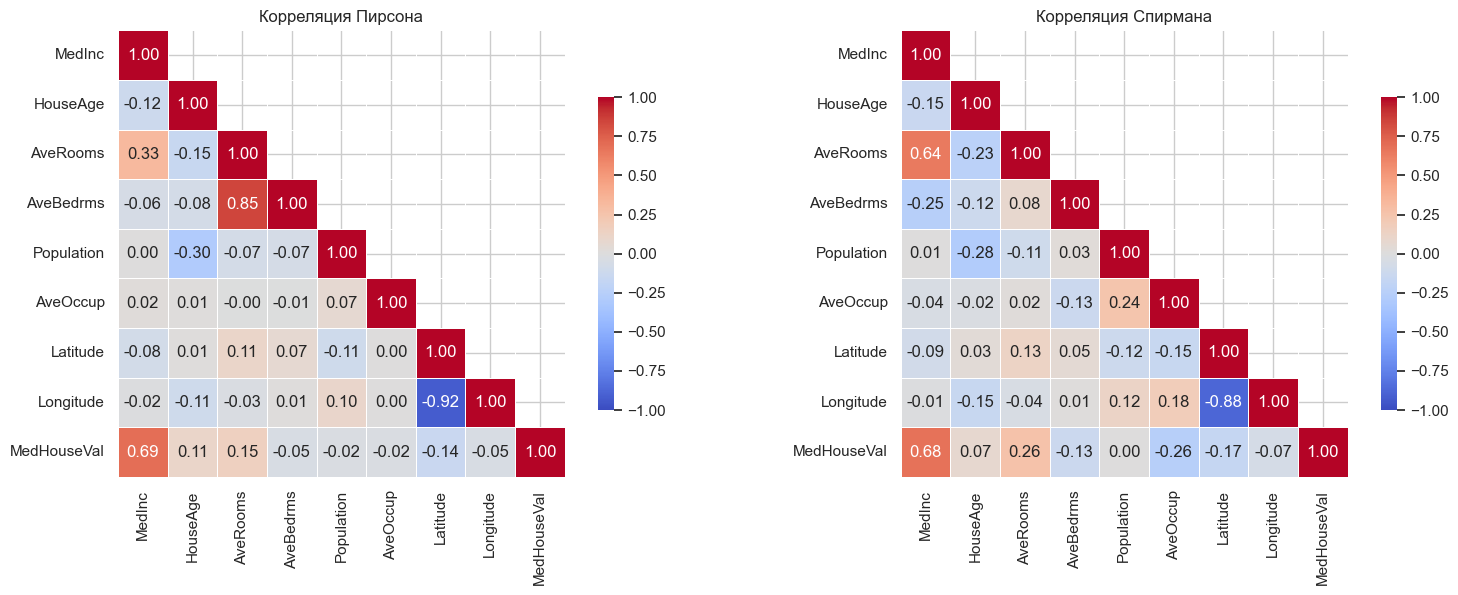

In [13]:
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ['Корреляция Пирсона', 'Корреляция Спирмана']
):
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    sns.heatmap(
        mat, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax
    )
    ax.set_title(title)
fig.tight_layout()
plt.show()

In [14]:
target_corr = (
    pd.DataFrame({
        'Пирсон': corr_pearson[TARGET].drop(TARGET),
        'Спирман': corr_spearman[TARGET].drop(TARGET),
    })
    .assign(**{'|Спирман − Пирсон|': lambda x: (x['Спирман'] - x['Пирсон']).abs()})
    .sort_values('Пирсон', key=abs, ascending=False)
)
target_corr

,Пирсон,Спирман,|Спирман − Пирсон|
MedInc,0.688,0.677,0.011
AveRooms,0.152,0.263,0.111
Latitude,-0.144,-0.166,0.022
HouseAge,0.106,0.075,0.031
AveBedrms,-0.047,-0.125,0.078
Longitude,-0.046,-0.070,0.024
Population,-0.025,0.004,0.028
AveOccup,-0.024,-0.257,0.233


**Выводы по корреляциям:**

* Наиболее сильно с целевой переменной связан `MedInc` (медианный доход) — корреляция Пирсона ≈ 0.69. Это согласуется с интуицией: чем выше доход в районе, тем дороже жильё.
* `Latitude` и `Longitude` имеют умеренную линейную корреляцию (~ −0.05/−0.05), однако зрительно на карте видно, что их вклад нелинейный — это видно по разнице между Пирсоном и Спирманом.
* `AveRooms` показывает слабую линейную связь, но более сильную ранговую (Спирман ≈ 0.4 против Пирсона ≈ 0.15) — это типичный признак нелинейной зависимости, искажённой выбросами.
* Между признаками `AveRooms` и `AveBedrms` корреляция близка к 0.85 — фактически они дублируют друг друга и могут вызвать мультиколлинеарность в линейных моделях.
* `Latitude` и `Longitude` сильно отрицательно скоррелированы (≈ −0.92) — следствие вытянутой формы Калифорнии (юг ↔ восток, север ↔ запад).

## Итоги

В ходе работы был выполнен разведочный анализ датасета **California Housing**:

1. Дано текстовое описание датасета: 20 640 наблюдений, 8 числовых признаков, регрессионная задача, пропусков нет.
2. Получены основные характеристики (типы, статистики, отсутствие пропусков).
3. Проведено визуальное исследование: гистограммы признаков и целевой переменной, боксплоты (на нормированных данных), географический scatter с раскраской по цене, pairplot ключевых признаков, hexbin joint plot для самой сильной пары.
4. Изучена корреляция: построены тепловые карты Пирсона и Спирмана, выделены ключевые связи (`MedInc` ↔ `MedHouseVal`, мультиколлинеарность `AveRooms`/`AveBedrms`, нелинейный вклад географии).

**Практические наблюдения для последующих работ:**

* Признаки `AveRooms`, `AveBedrms`, `Population`, `AveOccup` требуют обработки выбросов или логарифмирования.
* `MedHouseVal` искусственно ограничен сверху — это нужно учитывать в задаче регрессии.
* Перспективна нелинейная модель или явное добавление пространственных признаков (расстояние до побережья, до крупных городов).